# Privacy-Preserving Federated Network Intrusion Detection System

## Notebook 01 - Data Exploration

### Author
Mohammed Uzair Shaikh

### Objective

This notebook explores the CICIDS2017 dataset to understand its structure before preprocessing and model development.

### Tasks

- Load all CSV files
- Explore dataset dimensions
- Analyze missing values
- Check duplicate rows
- Explore attack distribution
- Generate visualizations
- Prepare for preprocessing

In [20]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [21]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "CICIDS2017"

PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

RESULTS_PATH = PROJECT_ROOT / "results"

FIGURES_PATH = RESULTS_PATH / "figures"

METRICS_PATH = RESULTS_PATH / "metrics"

for folder in [
    PROCESSED_DATA_PATH,
    FIGURES_PATH,
    METRICS_PATH
]:
    folder.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(RAW_DATA_PATH)

c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS
c:\MyFiles\Project\Privacy-Preserving-Federated-NIDS\data\raw\CICIDS2017


In [22]:
# =====================================================
# LOAD DATASET
# =====================================================

csv_files = sorted(RAW_DATA_PATH.glob("*.csv"))

datasets = {}

for file in csv_files:

    datasets[file.stem] = pd.read_csv(
        file,
        low_memory=False
    )

print(f"Datasets Loaded : {len(datasets)}")

Datasets Loaded : 8


In [23]:
# =====================================================
# DATASET SUMMARY
# =====================================================

summary = []

for name, df in datasets.items():

    summary.append({

        "Dataset": name,

        "Rows": df.shape[0],

        "Columns": df.shape[1],

        "Missing Values": df.isnull().sum().sum(),

        "Duplicate Rows": df.duplicated().sum(),

        "Memory (MB)": round(
            df.memory_usage(deep=True).sum()/1024**2,
            2
        )

    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Memory (MB)
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX,225745,79,4,2633,137.11
1,Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX,286467,79,15,72353,174.60
2,Friday-WorkingHours-Morning.pcap_ISCX,191033,79,28,6888,116.23
3,Monday-WorkingHours.pcap_ISCX,529918,79,64,26935,322.43
4,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,18,35630,175.60
5,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,20,6066,103.69
6,Tuesday-WorkingHours.pcap_ISCX,445909,79,201,24065,271.38
7,Wednesday-workingHours.pcap_ISCX,692703,79,1008,81909,422.07


In [24]:
# =====================================================
# DATASET FILES
# =====================================================

for i, name in enumerate(datasets.keys(), start=1):
    print(f"{i}. {name}")

1. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX
2. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX
3. Friday-WorkingHours-Morning.pcap_ISCX
4. Monday-WorkingHours.pcap_ISCX
5. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX
6. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX
7. Tuesday-WorkingHours.pcap_ISCX
8. Wednesday-workingHours.pcap_ISCX


In [25]:
# =====================================================
# SAMPLE DATA
# =====================================================

first_dataset = list(datasets.keys())[0]

print(f"Current Dataset : {first_dataset}")

datasets[first_dataset].head()

Current Dataset : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [26]:
# =====================================================
# DATASET INFORMATION
# =====================================================

datasets[first_dataset].info()

<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-null  float64


In [27]:
# =====================================================
# STATISTICAL SUMMARY
# =====================================================

datasets[first_dataset].describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,80.0,80.0,80.0,65532.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,71180.0,1452333.0,8805237.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,2.0,3.0,5.0,1932.0
Total Backward Packets,225745.0,4.572775e+00,2.175536e+01,0.0,1.0,4.0,5.0,2942.0
Total Length of Fwd Packets,225745.0,9.394633e+02,3.249403e+03,0.0,26.0,30.0,63.0,183012.0
...,...,...,...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,0.0,0.0,1862.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,0.0,0.0,8239725.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,0.0,0.0,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,0.0,0.0,8253838.0,120000000.0


In [30]:
# =====================================================
# MISSING VALUES
# =====================================================

missing = datasets[first_dataset].isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Flow Bytes/s    4
dtype: int64

In [29]:
# =====================================================
# DUPLICATE ROWS
# =====================================================

duplicates = datasets[first_dataset].duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 2633


In [31]:
# =====================================================
# ATTACK DISTRIBUTION
# =====================================================

label_column = datasets[first_dataset].columns[-1]

attack_distribution = datasets[first_dataset][label_column].value_counts()

attack_distribution

 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

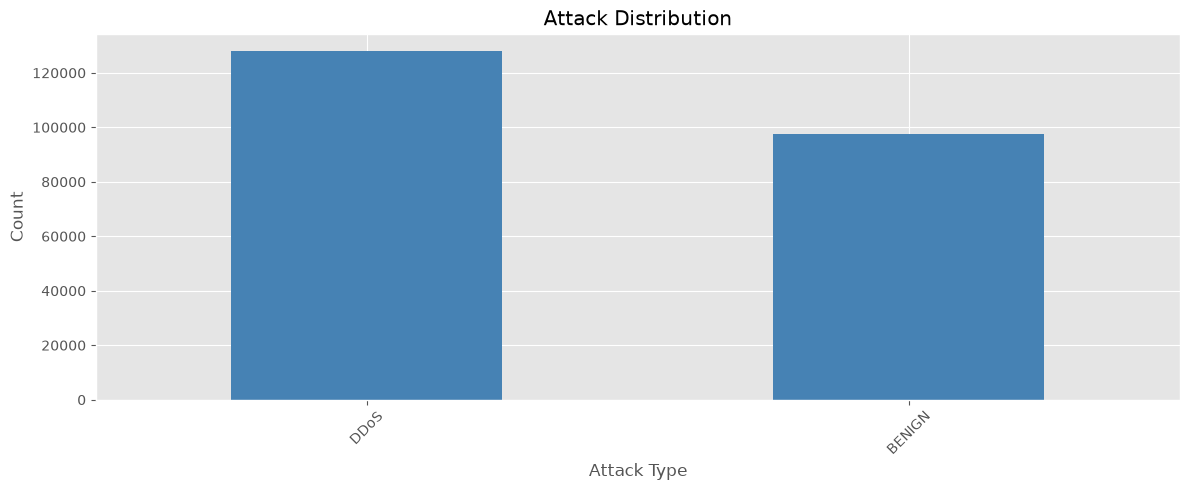

In [32]:
# =====================================================
# ATTACK DISTRIBUTION VISUALIZATION
# =====================================================

plt.figure(figsize=(12,5))

attack_distribution.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [33]:
# =====================================================
# DATASET SIZE COMPARISON
# =====================================================

fig = px.bar(
    summary_df,
    x="Dataset",
    y="Rows",
    color="Rows",
    title="Rows in Each Dataset"
)

fig.show()

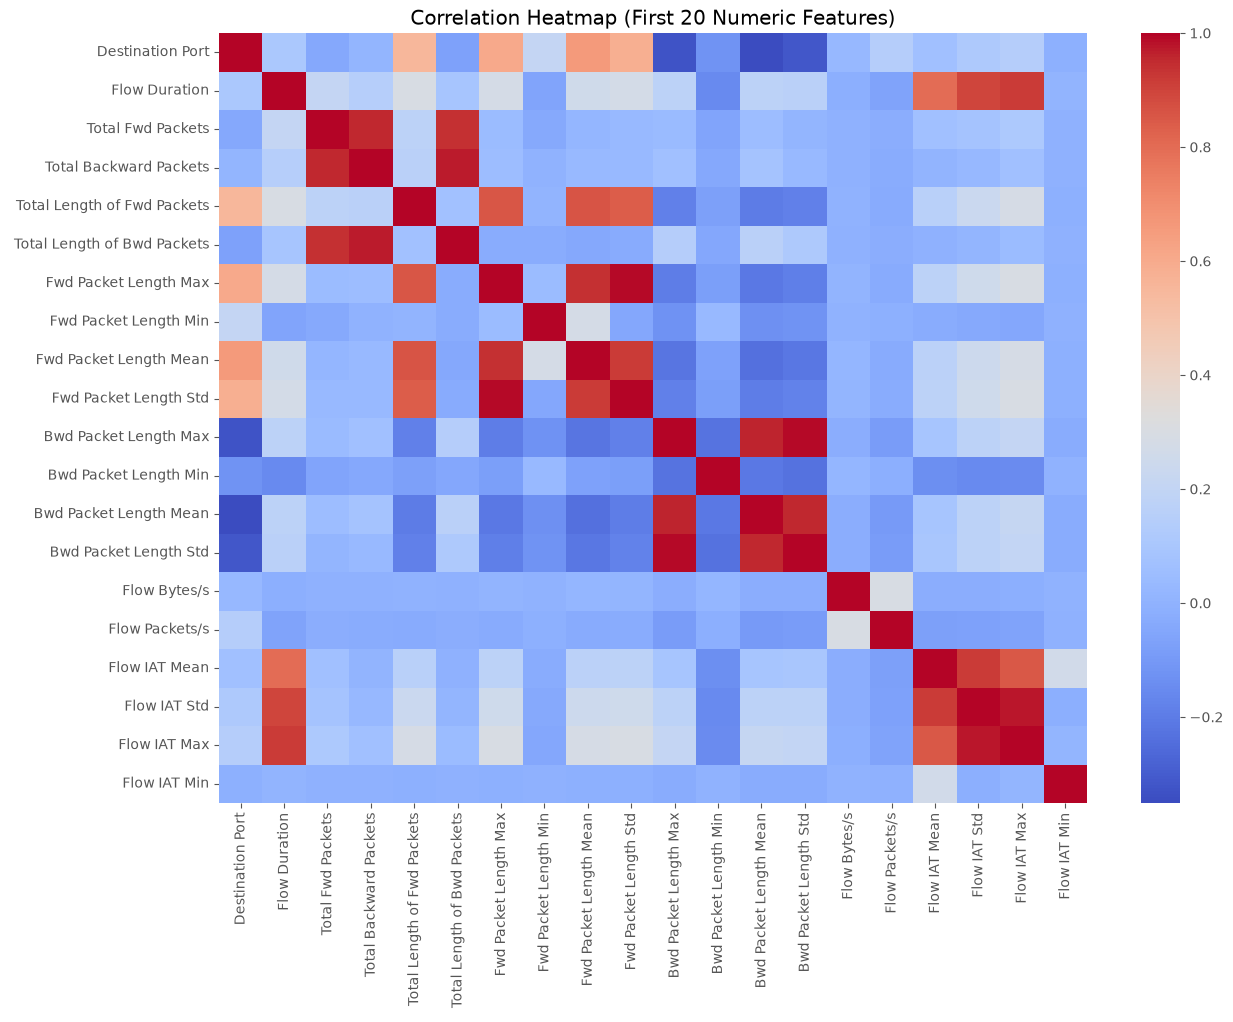

In [34]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

numeric_df = datasets[first_dataset].select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.iloc[:, :20].corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap (First 20 Numeric Features)")

plt.show()

In [35]:
# =====================================================
# SAVE SUMMARY
# =====================================================

summary_df.to_csv(
    METRICS_PATH / "dataset_summary.csv",
    index=False
)

print("Dataset summary saved successfully.")

Dataset summary saved successfully.


# Findings

### Observations

- Successfully loaded all 8 CSV files.
- Each dataset contains 79 input features and 1 label column.
- Multiple attack categories are present.
- Missing values exist and will be handled in preprocessing.
- Duplicate rows were identified.
- Correlation analysis shows some highly correlated features.